# Movement Strategy Simulation

This notebook simulates each movement strategy with the same `MotorController` setup used in `backend.py`, then analyzes:
- each motor command over time
- reconstructed tactor position from resulting motor outputs (not requested path)
- wire consistency issues (too tight / inconsistent trilateration residual)

Default pattern (fully configurable):
1. Start at `(0, 0)`
2. Move right from center to `50%` of half-width
3. One clockwise circle
4. Return to `(0, 0)`


In [2]:
import math
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

import sys
import os
# __file__ is not defined in Jupyter, so use os.getcwd() instead to set the parent directory
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from consts import EDGE_THRESHOLD, TOP_HEIGHT, TOP_WIDTH
from motor_controller import FingerId, HandOrientation, MotorController, MovementStrategy
from haptic_mapping import map_object_displacement_to_tactor

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


In [3]:
@dataclass
class SimulationConfig:
    # MotorController setup (mirrors backend usage)
    top_width: float = TOP_WIDTH
    top_height: float = TOP_HEIGHT
    edge_threshold: float = EDGE_THRESHOLD
    motor_spacing: float = 1000.0
    move_factor: float = 1.0
    diagonal_threshold: float = 0.5
    finger_id: FingerId = FingerId.INDEX
    hand_orientation: HandOrientation = HandOrientation.NOT_MIRRORED
    stiffness_value_normalized = 0.5

    # Pattern controls
    outward_fraction_of_half_width: float = 0.5
    # line_steps: int = 40
    # circle_steps: int = 220
    # return_steps: int = 40
    line_steps: int = 40
    circle_steps: int = 220
    return_steps: int = 40

    oppose_object_motion: bool = True
    # Analysis controls
    wire_residual_alert_threshold: float = 1.25

    # Live display controls
    live_plots: bool = False
    live_update_interval: int = 8


config = SimulationConfig()
config


SimulationConfig(top_width=640, top_height=480, edge_threshold=30, motor_spacing=1000.0, move_factor=1.0, diagonal_threshold=0.5, finger_id=<FingerId.INDEX: 1>, hand_orientation=<HandOrientation.NOT_MIRRORED: 'not_mirrored'>, outward_fraction_of_half_width=0.5, line_steps=40, circle_steps=220, return_steps=40, oppose_object_motion=True, wire_residual_alert_threshold=1.25, live_plots=False, live_update_interval=8)

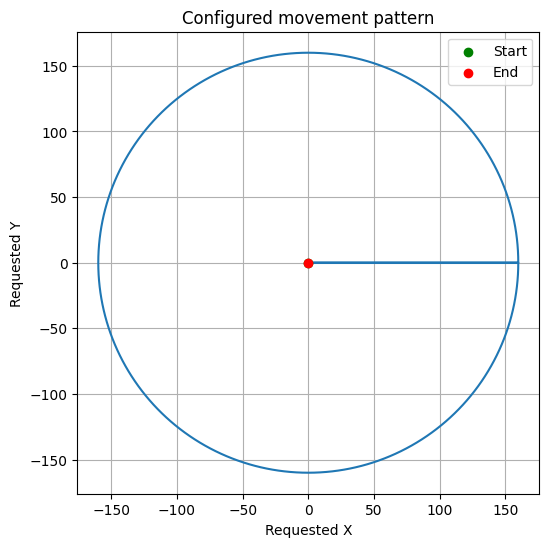

,step,segment,x,y
0,0,outward_right,0.0,0.0
1,1,outward_right,4.0,0.0
2,2,outward_right,8.0,0.0
3,3,outward_right,12.0,0.0
4,4,outward_right,16.0,0.0


In [4]:
DEFAULT_PATTERN_TEMPLATE: list[dict[str, Any]] = [
    {
        'type': 'line',
        'name': 'outward_right',
        'start': (0.0, 0.0),
        'end': '$OUTWARD_POINT',
        'steps': 'line_steps',
    },
    {
        'type': 'circle',
        'name': 'clockwise_circle',
        'center': (0.0, 0.0),
        'radius': '$OUTWARD_RADIUS',
        'start_angle_deg': 0.0,
        'sweep_angle_deg': -360.0,
        'steps': 'circle_steps',
    },
    {
        'type': 'line',
        'name': 'back_to_center',
        'start': '$OUTWARD_POINT',
        'end': (0.0, 0.0),
        'steps': 'return_steps',
    },
]


def _resolve_value(value: Any, context: dict[str, Any], cfg: SimulationConfig) -> Any:
    if isinstance(value, str):
        if value.startswith('$'):
            return context[value]
        if hasattr(cfg, value):
            return getattr(cfg, value)
    return value


def build_pattern_points(
    cfg: SimulationConfig,
    pattern_template: list[dict[str, Any]] | None = None,
) -> pd.DataFrame:
    template = pattern_template or DEFAULT_PATTERN_TEMPLATE

    half_width = cfg.top_width / 2.0
    outward_x = half_width * cfg.outward_fraction_of_half_width
    context = {
        '$OUTWARD_POINT': (outward_x, 0.0),
        '$OUTWARD_RADIUS': outward_x,
    }

    rows: list[dict[str, float | str]] = []
    include_start = True

    for segment in template:
        segment_type = str(segment['type'])
        segment_name = str(segment.get('name', segment_type))
        steps = int(_resolve_value(segment['steps'], context, cfg))
        if steps < 1:
            raise ValueError(f'Invalid steps for {segment_name}: {steps}')

        if segment_type == 'line':
            start = np.array(_resolve_value(segment['start'], context, cfg), dtype=float)
            end = np.array(_resolve_value(segment['end'], context, cfg), dtype=float)

            t_values = np.linspace(0.0, 1.0, num=steps + 1)
            if not include_start:
                t_values = t_values[1:]

            for t in t_values:
                point = start + t * (end - start)
                rows.append({'segment': segment_name, 'x': float(point[0]), 'y': float(point[1])})

        elif segment_type == 'circle':
            center = np.array(_resolve_value(segment['center'], context, cfg), dtype=float)
            radius = float(_resolve_value(segment['radius'], context, cfg))
            start_angle = math.radians(float(_resolve_value(segment.get('start_angle_deg', 0.0), context, cfg)))
            sweep_angle = math.radians(float(_resolve_value(segment.get('sweep_angle_deg', -360.0), context, cfg)))

            angles = np.linspace(start_angle, start_angle + sweep_angle, num=steps + 1)
            if not include_start:
                angles = angles[1:]

            for angle in angles:
                x = center[0] + radius * math.cos(angle)
                y = center[1] + radius * math.sin(angle)
                rows.append({'segment': segment_name, 'x': float(x), 'y': float(y)})

        else:
            raise ValueError(f'Unsupported segment type: {segment_type}')

        include_start = False

    path_df = pd.DataFrame(rows)
    path_df.insert(0, 'step', np.arange(len(path_df), dtype=int))
    return path_df


pattern_df = build_pattern_points(config)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pattern_df['x'], pattern_df['y'], linewidth=1.5)
ax.scatter(pattern_df.iloc[0]['x'], pattern_df.iloc[0]['y'], color='green', label='Start', zorder=3)
ax.scatter(pattern_df.iloc[-1]['x'], pattern_df.iloc[-1]['y'], color='red', label='End', zorder=3)
ax.set_title('Configured movement pattern')
ax.set_xlabel('Requested X')
ax.set_ylabel('Requested Y')
ax.set_aspect('equal', 'box')
ax.legend()
plt.show()

pattern_df.head()


In [5]:
def get_motor_anchors(motor_spacing: float) -> np.ndarray:
    h = motor_spacing * math.sqrt(3.0) / 3.0
    # Clockwise motor order: 0=top, 1=bottom-right, 2=bottom-left
    return np.array(
        [
            [0.0, 2.0 * h / 3.0],
            [motor_spacing / 2.0, -h / 3.0],
            [-motor_spacing / 2.0, -h / 3.0],
        ],
        dtype=float,
    )


def reconstruct_tactor_xy(
    final_lengths: np.ndarray,
    anchors: np.ndarray,
) -> tuple[float, float, float, np.ndarray, np.ndarray]:
    # Linearized trilateration from three anchor distances
    p1 = anchors[0]
    r1 = final_lengths[0]

    A = []
    b = []
    for i in (1, 2):
        xi, yi = anchors[i]
        ri = final_lengths[i]
        A.append([2.0 * (xi - p1[0]), 2.0 * (yi - p1[1])])
        b.append(
            (r1 ** 2 - ri ** 2)
            - (p1[0] ** 2 - xi ** 2)
            - (p1[1] ** 2 - yi ** 2)
        )

    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    solution, *_ = np.linalg.lstsq(A, b, rcond=None)
    x = float(solution[0])
    y = float(solution[1])

    predicted_lengths = np.linalg.norm(anchors - np.array([x, y]), axis=1)
    length_error = predicted_lengths - final_lengths
    residual_rmse = float(np.sqrt(np.mean(length_error ** 2)))

    return x, y, residual_rmse, predicted_lengths, length_error


In [6]:
def show_live_state(partial_df: pd.DataFrame, strategy_name: str, alert_threshold: float) -> None:
    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    idx0 = int(partial_df['motor_index_0'].iloc[0])
    idx1 = int(partial_df['motor_index_1'].iloc[0])
    idx2 = int(partial_df['motor_index_2'].iloc[0])

    axes[0].plot(partial_df['step'], partial_df['motor_0'], label=f'Motor {idx0}')
    axes[0].plot(partial_df['step'], partial_df['motor_1'], label=f'Motor {idx1}')
    axes[0].plot(partial_df['step'], partial_df['motor_2'], label=f'Motor {idx2}')
    axes[0].set_title(f'{strategy_name}: motor commands')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Motor position command')
    axes[0].legend()

    axes[1].plot(partial_df['object_x'], partial_df['object_y'], '--', label='Virtual object path', alpha=0.8)
    axes[1].plot(partial_df['tactor_x'], partial_df['tactor_y'], label='Reconstructed tactor', linewidth=2)

    issues = partial_df[partial_df['wire_issue']]
    if not issues.empty:
        axes[1].scatter(issues['tactor_x'], issues['tactor_y'], c='red', s=20, label='Wire issue')

    axes[1].set_title(f'{strategy_name}: virtual object vs reconstructed tactor')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_aspect('equal', 'box')
    axes[1].legend(loc='upper right')

    fig.suptitle(f'Live update | issue threshold={alert_threshold:.2f}', y=1.03)
    plt.tight_layout()
    display(fig)
    plt.close(fig)


def simulate_strategy(
    strategy: MovementStrategy,
    pattern: pd.DataFrame,
    cfg: SimulationConfig,
) -> pd.DataFrame:
    controller = MotorController(
        movement_strategy=strategy,
        top_width=cfg.top_width,
        top_height=cfg.top_height,
        edge_threshold=cfg.edge_threshold,
        motor_spacing=cfg.motor_spacing,
        move_factor=cfg.move_factor,
        diagonal_threshold=cfg.diagonal_threshold,
        hand_orientation=cfg.hand_orientation,
    )

    base_idx = controller._get_base_index(cfg.finger_id)
    motor_indices = [base_idx + i for i in range(3)]
    current_motor_positions = {idx: 0 for idx in motor_indices}

    anchors = get_motor_anchors(controller._motor_spacing)
    initial_lengths = np.linalg.norm(anchors - np.array([0.0, 0.0]), axis=1)

    rows: list[dict[str, Any]] = []

    final_step = int(pattern['step'].iat[-1])
    update_every = max(1, cfg.live_update_interval)

    for _, point in pattern.iterrows():
        step = int(point['step'])
        object_x = float(point['x'])
        object_y = float(point['y'])
        segment = str(point['segment'])

        target_x, target_y = map_object_displacement_to_tactor(
            obj_x=object_x,
            obj_y=object_y,
            oppose_motion=cfg.oppose_object_motion,
        )

        movements = controller.calculate_motor_movements(
            finger_id=cfg.finger_id,
            stiffness_value=cfg.stiffness_value_normalized,
            obj_x=target_x,
            obj_y=target_y,
            motors_enabled=True,
            reset_to_origin=False,
        )

        for movement in movements:
            if movement.index in current_motor_positions:
                current_motor_positions[movement.index] = movement.pos

        motor_offsets = np.array([current_motor_positions[idx] for idx in motor_indices], dtype=float)
        final_lengths = initial_lengths + motor_offsets

        wire_too_tight = bool(np.any(final_lengths <= 0.0))
        if wire_too_tight:
            tactor_x = float('nan')
            tactor_y = float('nan')
            residual_rmse = float('inf')
            length_error = np.array([float('nan'), float('nan'), float('nan')], dtype=float)
            dominant_wire_motor_index = -1
            dominant_wire_error = float('nan')
        else:
            tactor_x, tactor_y, residual_rmse, _, length_error = reconstruct_tactor_xy(final_lengths, anchors)
            dominant_wire_idx = int(np.argmax(np.abs(length_error)))
            dominant_wire_motor_index = motor_indices[dominant_wire_idx]
            dominant_wire_error = float(abs(length_error[dominant_wire_idx]))

        tactor_error = float('nan')
        if not math.isnan(tactor_x) and not math.isnan(tactor_y):
            tactor_error = float(math.hypot(tactor_x - target_x, tactor_y - target_y))

        wire_issue = wire_too_tight or (residual_rmse > cfg.wire_residual_alert_threshold)

        rows.append(
            {
                'strategy': strategy.value,
                'step': step,
                'segment': segment,
                'object_x': object_x,
                'object_y': object_y,
                'target_x': target_x,
                'target_y': target_y,
                'motor_index_0': motor_indices[0],
                'motor_index_1': motor_indices[1],
                'motor_index_2': motor_indices[2],
                'motor_0': float(motor_offsets[0]),
                'motor_1': float(motor_offsets[1]),
                'motor_2': float(motor_offsets[2]),
                'wire_length_0': float(final_lengths[0]),
                'wire_length_1': float(final_lengths[1]),
                'wire_length_2': float(final_lengths[2]),
                'tactor_x': tactor_x,
                'tactor_y': tactor_y,
                'tactor_error': tactor_error,
                'wire_residual_rmse': float(residual_rmse),
                'wire_too_tight': wire_too_tight,
                'wire_issue': wire_issue,
                'dominant_wire_motor_index': dominant_wire_motor_index,
                'dominant_wire_error': dominant_wire_error,
            }
        )

        if cfg.live_plots and (step % update_every == 0 or step == final_step):
            show_live_state(pd.DataFrame(rows), strategy.value, cfg.wire_residual_alert_threshold)

    return pd.DataFrame(rows)


In [7]:
strategies = [
    MovementStrategy.CARDINAL,
    MovementStrategy.CARDINAL_DIAGONAL,
    MovementStrategy.FREE_FORM,
]

pattern_df = build_pattern_points(config)
results = [simulate_strategy(strategy, pattern_df, config) for strategy in strategies]
all_results = pd.concat(results, ignore_index=True)

print(f'Path points: {len(pattern_df)}')
print(f'Strategies: {len(strategies)}')
print(f'Total rows: {len(all_results)}')
all_results.head()


Path points: 301
Strategies: 3
Total rows: 903


,strategy,step,segment,object_x,object_y,target_x,target_y,motor_index_0,motor_index_1,motor_index_2,...,wire_length_1,wire_length_2,tactor_x,tactor_y,tactor_error,wire_residual_rmse,wire_too_tight,wire_issue,dominant_wire_motor_index,dominant_wire_error
0,cardinal,0,outward_right,0.0,0.0,-0.0,-0.0,3,4,5,...,535.758376,535.758376,0.000000,-5.040931e-14,5.040931e-14,3.281856e-14,False,False,3,5.684342e-14
1,cardinal,1,outward_right,4.0,0.0,-4.0,-0.0,3,4,5,...,536.758376,534.758376,-1.071517,8.660254e-04,2.928483e+00,5.147921e-04,False,False,3,6.254633e-04
2,cardinal,2,outward_right,8.0,0.0,-8.0,-0.0,3,4,5,...,538.758376,532.758376,-3.214550,7.794229e-03,4.785456e+00,4.633262e-03,False,False,3,5.629203e-03
3,cardinal,3,outward_right,12.0,0.0,-12.0,-0.0,3,4,5,...,540.758376,530.758376,-5.357584,2.165064e-02,6.642452e+00,1.287091e-02,False,False,3,1.563686e-02
4,cardinal,4,outward_right,16.0,0.0,-16.0,-0.0,3,4,5,...,542.758376,528.758376,-7.500617,4.243524e-02,8.499489e+00,2.522917e-02,False,False,3,3.064880e-02


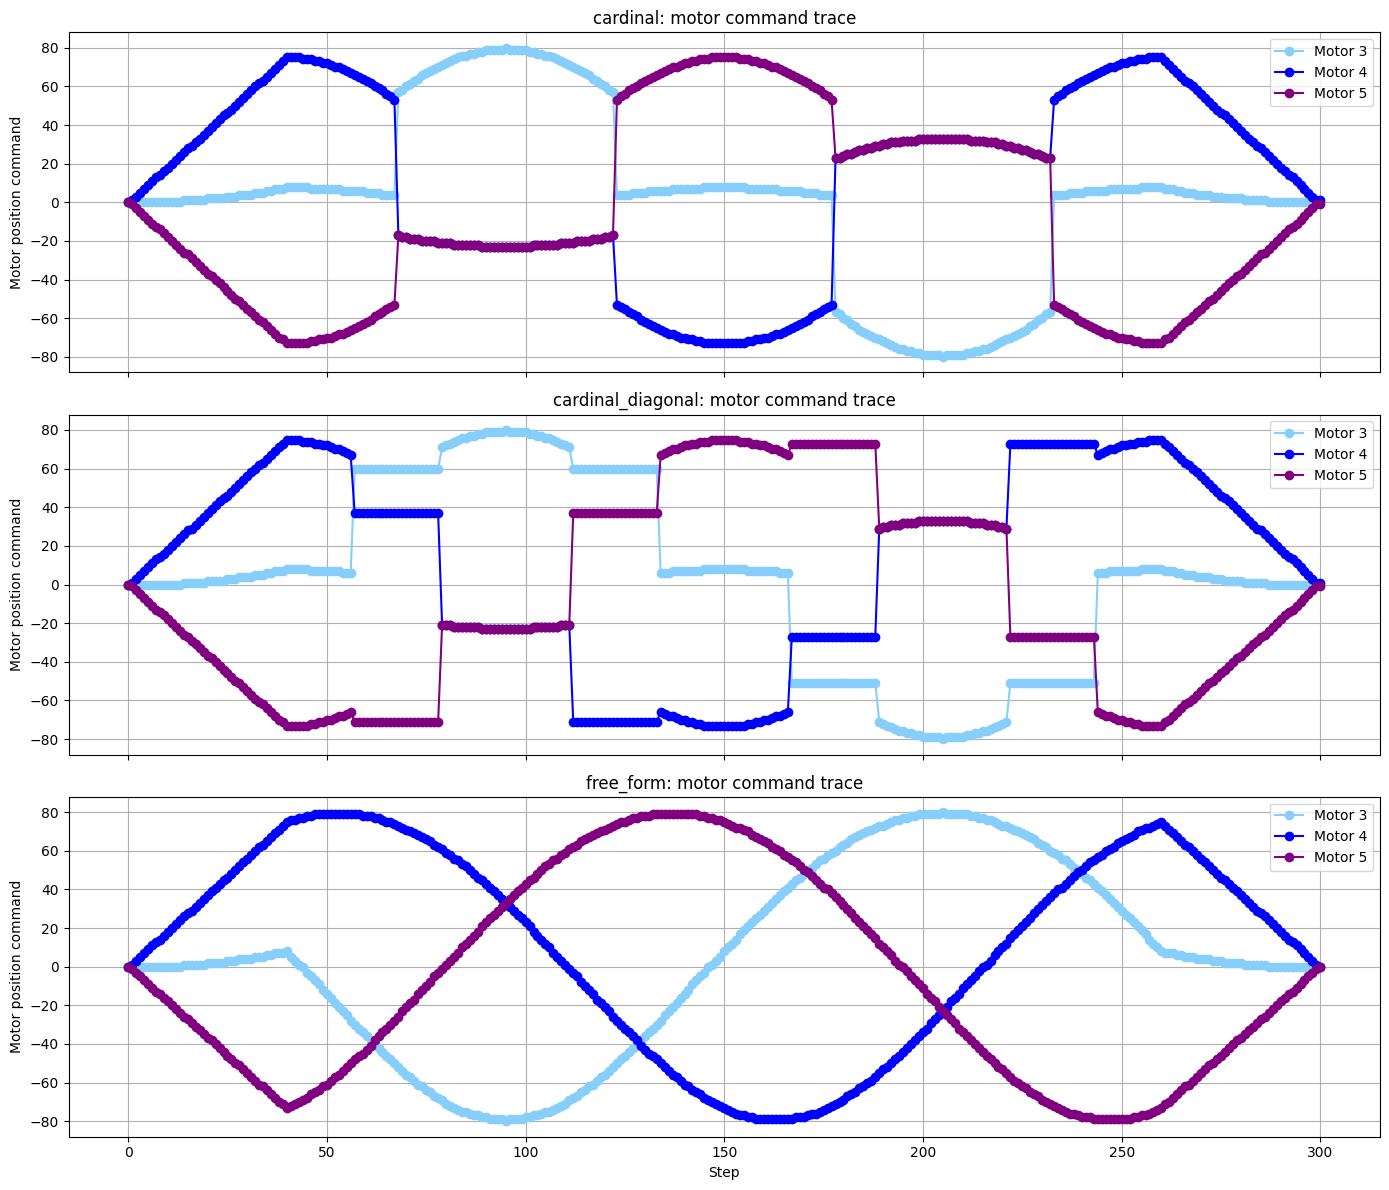

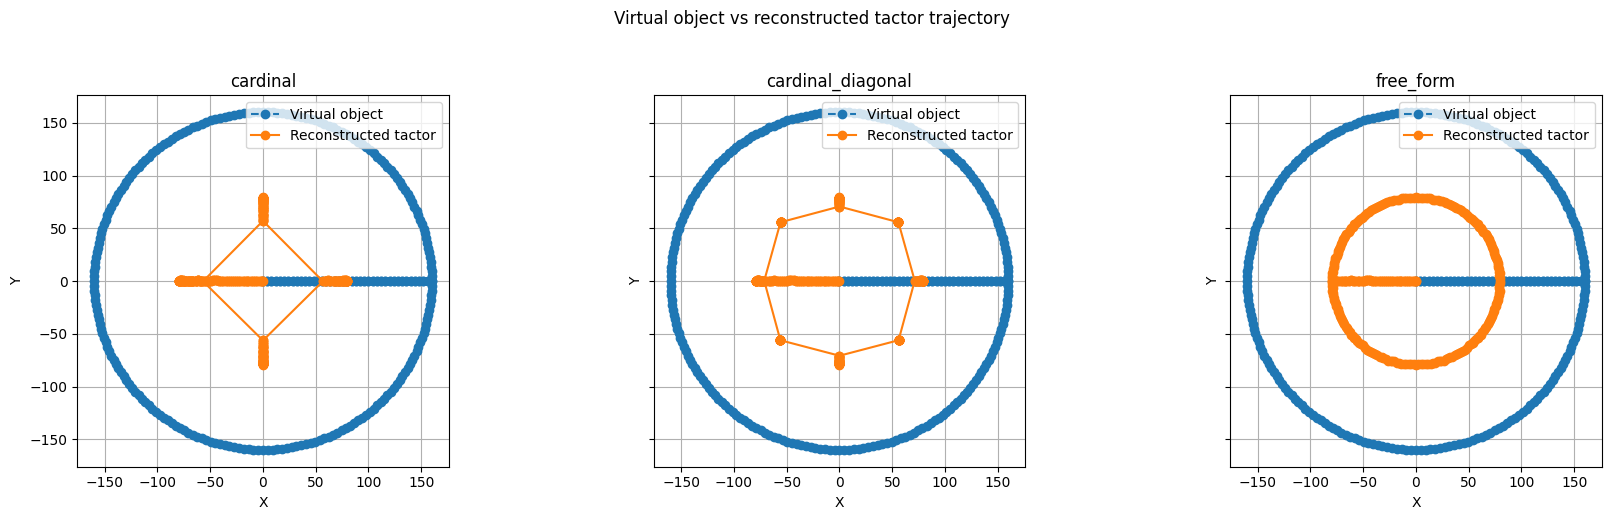

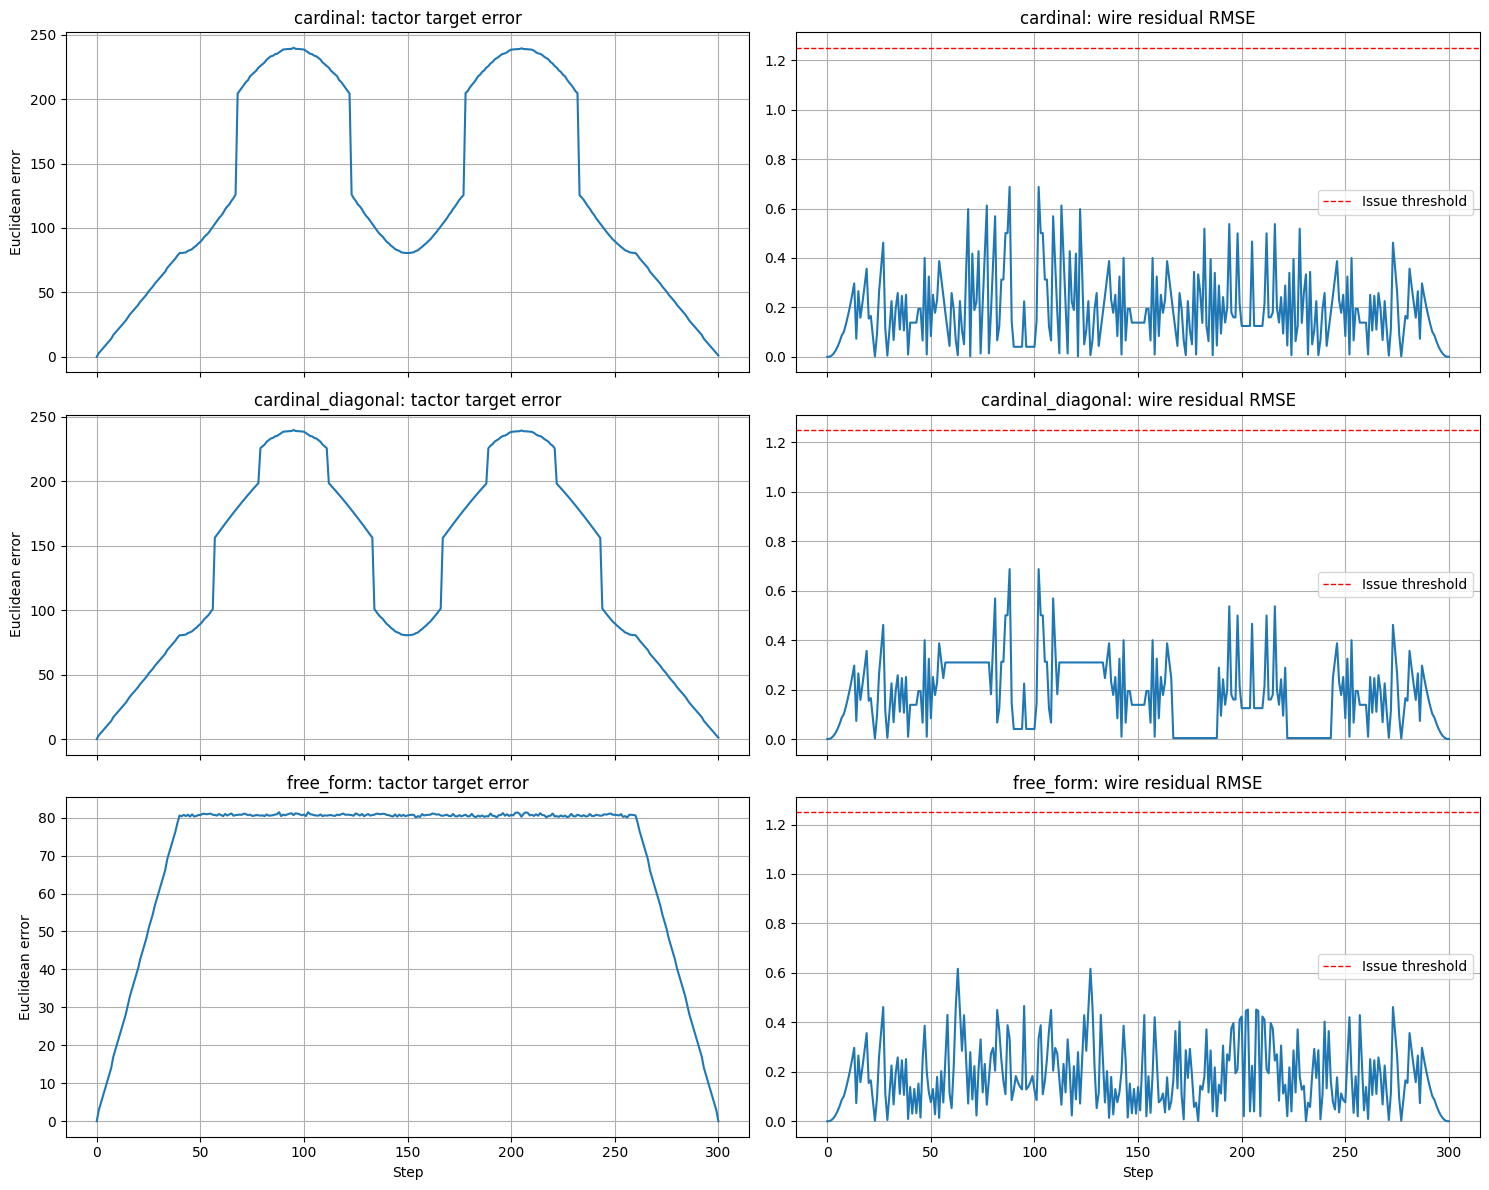

Strategy summary:


,mean_tactor_error,max_tactor_error,mean_wire_residual,max_wire_residual,issue_steps,issue_ratio
strategy,,,,,,
cardinal,129.653204,239.760865,0.192927,0.687400,0,0.0
cardinal_diagonal,133.575016,239.760865,0.182087,0.687400,0,0.0
free_form,69.727847,81.426193,0.185714,0.616566,0,0.0


No wire consistency issues detected at the configured threshold.


In [8]:
def evenly_sample_steps(part: pd.DataFrame, sample_count: int) -> pd.DataFrame:
    if sample_count < 2:
        raise ValueError('sample_count must be at least 2.')

    if part.empty:
        return part

    sampled_len = min(sample_count, len(part))
    sampled_indices = np.linspace(0, len(part) - 1, num=sampled_len, dtype=int)
    sampled_indices = np.unique(sampled_indices)
    return part.iloc[sampled_indices]

def plot_motor_movements(df: pd.DataFrame, sample_count: int | None) -> None:
    strategy_names = [s.value for s in strategies]
    motor_colors = {
        0: 'lightskyblue',
        1: 'blue',
        2: 'purple',
    }
    fig, axes = plt.subplots(len(strategy_names), 1, figsize=(14, 4 * len(strategy_names)), sharex=True)
    if len(strategy_names) == 1:
        axes = [axes]

    for i, strategy_name in enumerate(strategy_names):
        ax = axes[i]
        part = df[df['strategy'] == strategy_name].reset_index(drop=True)
        if sample_count:
            part = evenly_sample_steps(part, sample_count)
        idx0 = int(part['motor_index_0'].iloc[0])
        idx1 = int(part['motor_index_1'].iloc[0])
        idx2 = int(part['motor_index_2'].iloc[0])

        ax.plot(part['step'], part['motor_0'], '-o', label=f'Motor {idx0}', color=motor_colors[0])
        ax.plot(part['step'], part['motor_1'], '-o', label=f'Motor {idx1}', color=motor_colors[1])
        ax.plot(part['step'], part['motor_2'], '-o', label=f'Motor {idx2}', color=motor_colors[2])
        ax.set_title(f'{strategy_name}: motor command trace' + (f' ({len(part)} samples)' if sample_count else ''))
        ax.set_ylabel('Motor position command')
        ax.legend()

    axes[-1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()

def plot_tactor_paths(df: pd.DataFrame, sample_count: int | None) -> None:
    strategy_names = [s.value for s in strategies]
    fig, axes = plt.subplots(1, len(strategy_names), figsize=(6 * len(strategy_names), 5), sharex=True, sharey=True)
    if len(strategy_names) == 1:
        axes = [axes]

    for i, strategy_name in enumerate(strategy_names):
        ax = axes[i]
        part = df[df['strategy'] == strategy_name].reset_index(drop=True)
        if sample_count:
            part = evenly_sample_steps(part, sample_count)

        ax.plot(part['object_x'], part['object_y'], '--o', label='Virtual object')
        ax.plot(part['tactor_x'], part['tactor_y'], '-o', label='Reconstructed tactor')

        issues = part[part['wire_issue']]
        if not issues.empty:
            ax.scatter(issues['tactor_x'], issues['tactor_y'], c='red', s=18, label='Wire issue')

        ax.set_title(f'{strategy_name}' + (f' ({len(part)} samples)' if sample_count else ''))
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_aspect('equal', 'box')
        ax.legend(loc='upper right')

    plt.suptitle('Virtual object vs reconstructed tactor trajectory', y=1.03)
    plt.tight_layout()
    plt.show()


def plot_error_metrics(df: pd.DataFrame, alert_threshold: float) -> None:
    strategy_names = [s.value for s in strategies]
    fig, axes = plt.subplots(len(strategy_names), 2, figsize=(15, 4 * len(strategy_names)), sharex=True)
    if len(strategy_names) == 1:
        axes = np.array([axes])

    for i, strategy_name in enumerate(strategy_names):
        part = df[df['strategy'] == strategy_name]

        axes[i, 0].plot(part['step'], part['tactor_error'])
        axes[i, 0].set_title(f'{strategy_name}: tactor target error')
        axes[i, 0].set_ylabel('Euclidean error')

        axes[i, 1].plot(part['step'], part['wire_residual_rmse'])
        axes[i, 1].axhline(alert_threshold, color='red', linestyle='--', linewidth=1, label='Issue threshold')
        axes[i, 1].set_title(f'{strategy_name}: wire residual RMSE')
        axes[i, 1].legend()

    axes[-1, 0].set_xlabel('Step')
    axes[-1, 1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()


plot_motor_movements(all_results, sample_count=0)
plot_tactor_paths(all_results, sample_count=0)
plot_error_metrics(all_results, config.wire_residual_alert_threshold)

summary_source = all_results.replace([np.inf, -np.inf], np.nan)
summary = (
    summary_source.groupby('strategy')
    .agg(
        mean_tactor_error=('tactor_error', 'mean'),
        max_tactor_error=('tactor_error', 'max'),
        mean_wire_residual=('wire_residual_rmse', 'mean'),
        max_wire_residual=('wire_residual_rmse', 'max'),
        issue_steps=('wire_issue', 'sum'),
        issue_ratio=('wire_issue', 'mean'),
    )
    .sort_index()
)

print('Strategy summary:')
display(summary)

issues = all_results[all_results['wire_issue']].copy()
if issues.empty:
    print('No wire consistency issues detected at the configured threshold.')
else:
    print(f'Wire issues detected in {len(issues)} steps.')
    issue_cols = [
        'strategy',
        'step',
        'segment',
        'target_x',
        'target_y',
        'tactor_x',
        'tactor_y',
        'wire_too_tight',
        'wire_residual_rmse',
        'dominant_wire_motor_index',
        'dominant_wire_error',
    ]
    display(issues[issue_cols].head(100))


## Unified IK actuator-space comparison

This section keeps the existing movement simulation unchanged and adds a parallel calculation path:

`target tactor position -> unified IK -> wire attachment point -> wire length delta -> spool rotation`

The physical constants are exposed below so they can be adjusted after measuring the device.

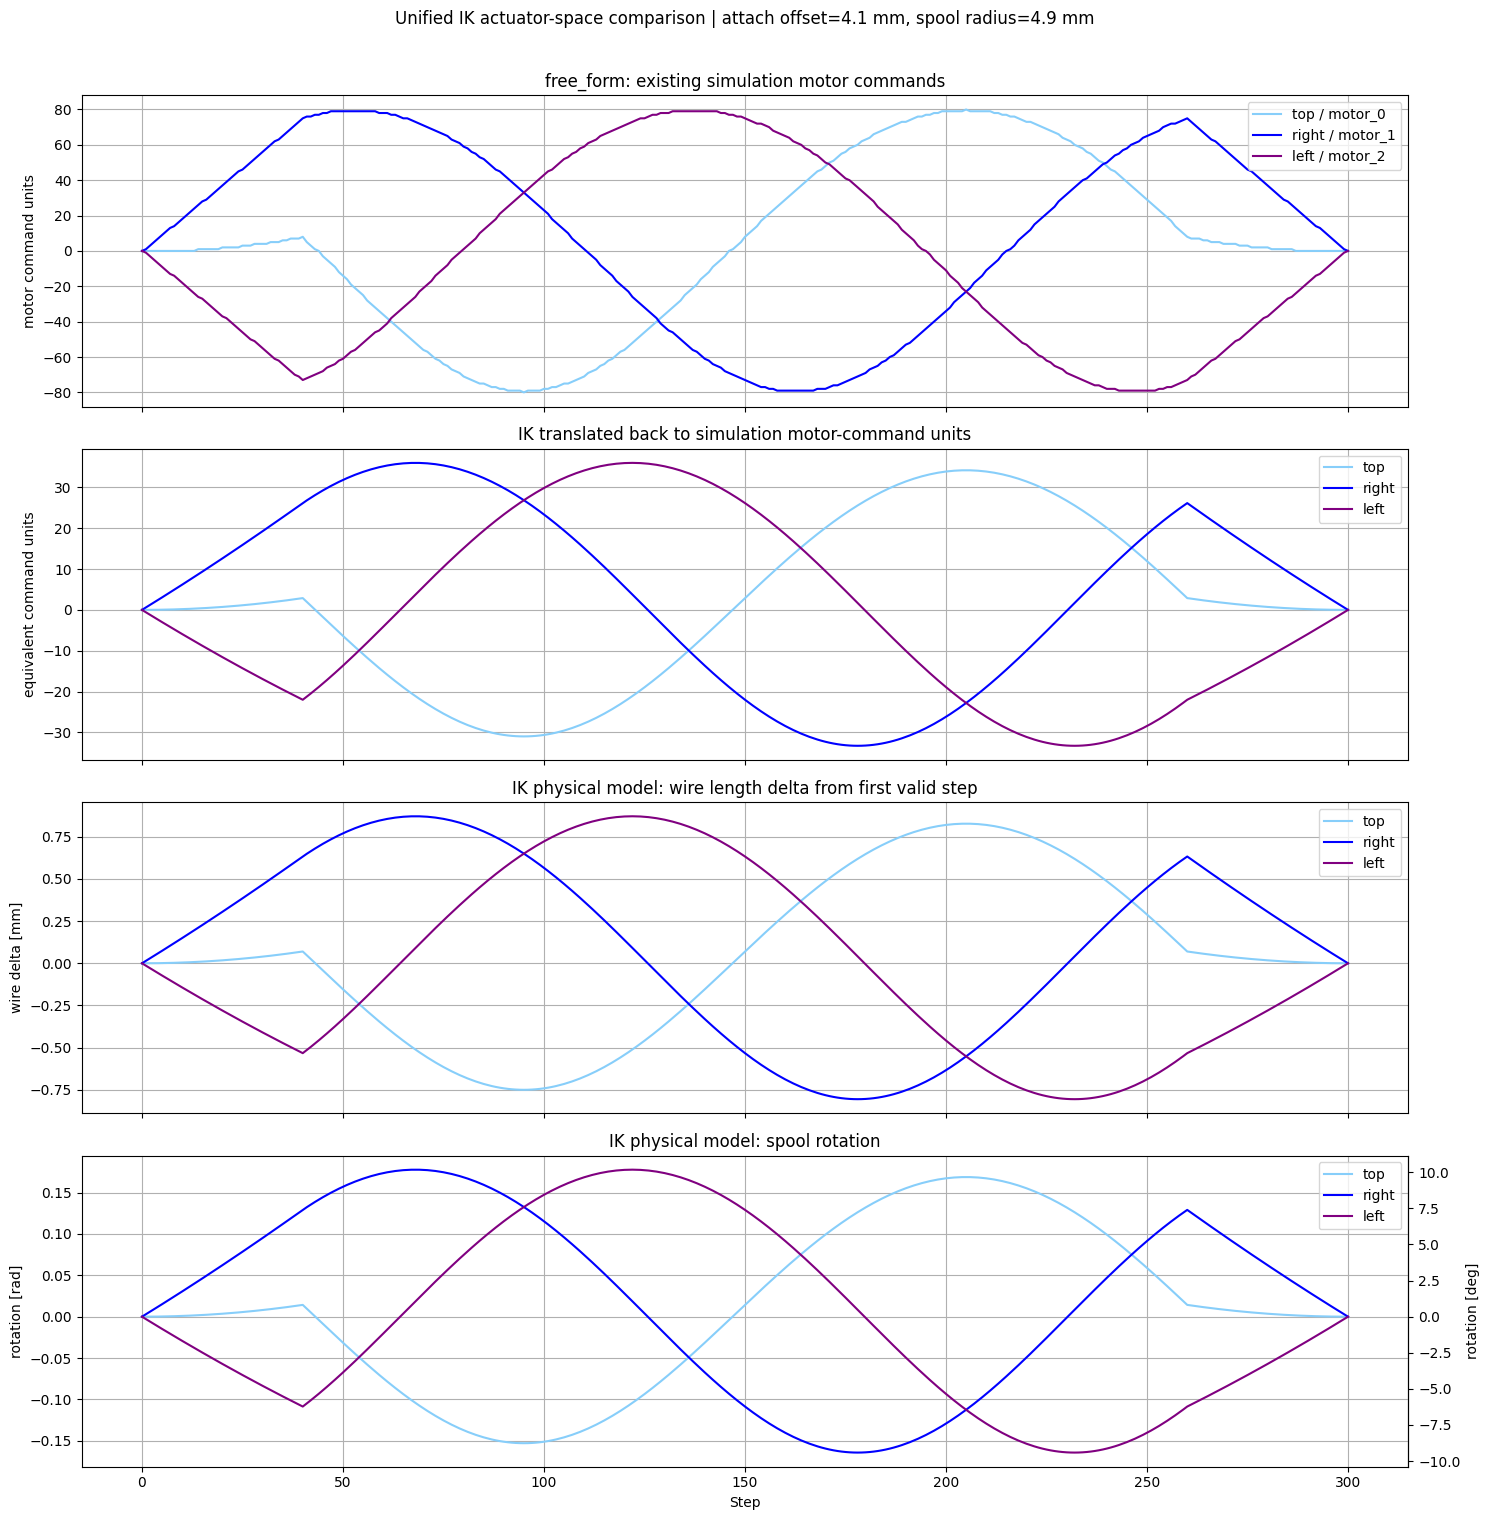

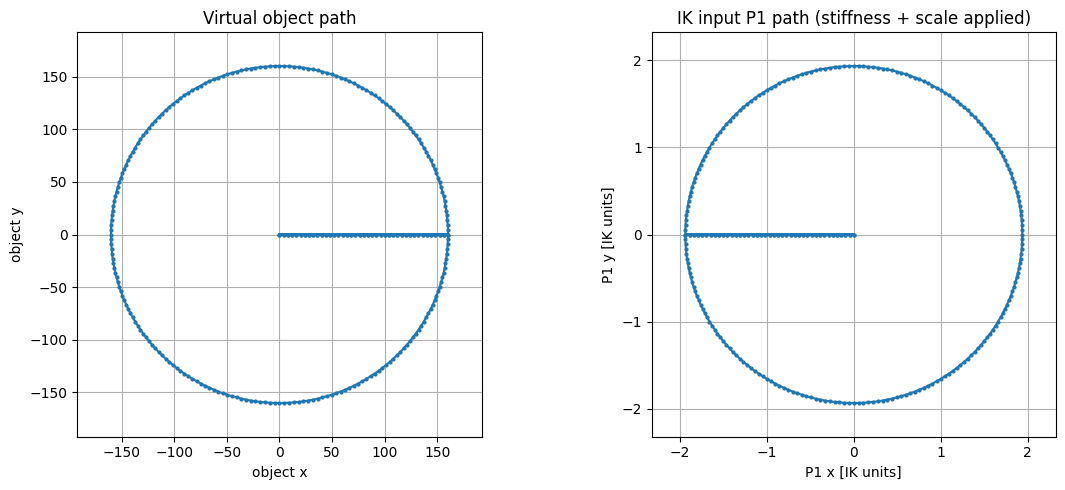

IK actuator-space summary:


,leg,valid_steps,invalid_steps,wire_reference_mm,wire_delta_min_mm,wire_delta_max_mm,motor_equivalent_min,motor_equivalent_max,spool_rotation_min_rad,spool_rotation_max_rad,spool_rotation_min_deg,spool_rotation_max_deg
0,top,301,0,9.967895,-0.749339,0.827017,-30.964429,34.174256,-0.152926,0.168779,-8.762035,9.670323
1,right,301,0,10.531645,-0.804911,0.870801,-33.260782,35.983508,-0.164268,0.177714,-9.411836,10.182289
2,left,301,0,10.531645,-0.804911,0.870801,-33.260782,35.983508,-0.164268,0.177714,-9.411836,10.182289


All IK steps were valid for all legs.
Backend scaling note: backend.py uses MOVE_FACTOR=3 and opposing tactor motion. This comparison uses the existing notebook results as-is: move_factor=1.0, oppose_object_motion=True, stiffness=0.5. Coordinates sent to IK are motor_target * SIM_TO_IK_SCALE, where SIM_TO_IK_SCALE=0.024200 (1000.0 simulation units -> 24.20 IK mm). IK wire deltas are also multiplied by IK_TO_SIM_SCALE=41.322 for the motor-equivalent comparison.


In [9]:
import importlib
import sys
from pathlib import Path

IK_DIR = Path(r'C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Kinematics\SRR_IK_new model')
if not IK_DIR.exists():
    raise FileNotFoundError(f'IK folder was not found: {IK_DIR}')
if str(IK_DIR) not in sys.path:
    sys.path.insert(0, str(IK_DIR))

import unified_ik_starter as ik
ik = importlib.reload(ik)

IK_LEGS = ('top', 'right', 'left')
LEG_TO_MOTOR_COLUMN = {
    'top': 'motor_0',
    'right': 'motor_1',
    'left': 'motor_2',
}
LEG_COLORS = {
    'top': 'lightskyblue',
    'right': 'blue',
    'left': 'purple',
}

# Physical model constants, in the same millimeter-like units as the IK model.
IK_Z_TACTOR = 8.62
IK_PHI1 = math.pi / 2.0
WIRE_ATTACH_OFFSET_MM = 4.1
SPOOL_RADIUS_MM = 4.9

# Backend scaling context. The existing notebook simulation uses its current config;
# these constants document the live backend defaults for interpretation.
BACKEND_MOVE_FACTOR = 3
BACKEND_OPPOSES_OBJECT_MOTION = True

# Convert between the notebook motor-controller units and the IK model units.
# motor_spacing is the simulated distance between right/left motors; the IK uses
# the right/left anchor distance as the corresponding physical span.
IK_REFERENCE_MODEL = ik.default_model()
IK_BASE_SPAN_MM = float(
    np.linalg.norm(
        np.asarray(IK_REFERENCE_MODEL['anchors']['right'], dtype=float)
        - np.asarray(IK_REFERENCE_MODEL['anchors']['left'], dtype=float)
    )
)
SIM_BASE_SPAN_UNITS = float(config.motor_spacing)
SIM_TO_IK_SCALE = IK_BASE_SPAN_MM / SIM_BASE_SPAN_UNITS
IK_TO_SIM_SCALE = 1.0 / SIM_TO_IK_SCALE


def _as_vector(point: tuple[float, float, float] | None) -> np.ndarray:
    if point is None:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return np.asarray(point, dtype=float)


def _unit_vector(vector: np.ndarray) -> np.ndarray:
    norm = float(np.linalg.norm(vector))
    if norm == 0.0 or not np.isfinite(norm):
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return vector / norm


def _angle_snapshot(result: dict[str, Any]) -> dict[str, dict[str, float]]:
    snapshot: dict[str, dict[str, float]] = {}
    for leg in IK_LEGS:
        leg_result = result[leg]
        if leg_result['valid']:
            snapshot[leg] = {
                'phi2': leg_result['phi2'],
                'phi3': leg_result['phi3'],
                'phi4': leg_result['phi4'],
                'phi5': leg_result['phi5'],
                'phi6': leg_result['phi6'],
            }
    return snapshot


def _effective_motor_target(target_x: float, target_y: float, cfg: SimulationConfig) -> tuple[float, float]:
    if cfg.hand_orientation == HandOrientation.MIRRORED:
        target_x = -target_x
    return (
        target_x * cfg.stiffness_value_normalized,
        target_y * cfg.stiffness_value_normalized,
    )


def _add_leg_actuator_columns(ik_df: pd.DataFrame) -> pd.DataFrame:
    out = ik_df.copy()
    for leg in IK_LEGS:
        wire_col = f'{leg}_wire_length'
        ref_idx = out[wire_col].first_valid_index()
        ref_length = float(out.loc[ref_idx, wire_col]) if ref_idx is not None else np.nan
        out[f'{leg}_wire_reference'] = ref_length
        out[f'{leg}_wire_delta'] = out[wire_col] - ref_length
        out[f'{leg}_motor_equivalent'] = out[f'{leg}_wire_delta'] * IK_TO_SIM_SCALE
        out[f'{leg}_spool_rotation_rad'] = out[f'{leg}_wire_delta'] / SPOOL_RADIUS_MM
        out[f'{leg}_spool_rotation_deg'] = np.degrees(out[f'{leg}_spool_rotation_rad'])
    return out


def run_ik_actuator_space_on_simulation(
    simulation_results: pd.DataFrame,
    strategy: MovementStrategy = MovementStrategy.FREE_FORM,
    z_tactor: float = IK_Z_TACTOR,
    phi1: float = IK_PHI1,
) -> pd.DataFrame:
    strategy_name = strategy.value if isinstance(strategy, MovementStrategy) else str(strategy)
    source = simulation_results[simulation_results['strategy'] == strategy_name].reset_index(drop=True)
    if source.empty:
        raise ValueError(f'No simulation rows found for strategy={strategy_name!r}')

    model = ik.default_model()
    previous_angles: dict[str, dict[str, float]] | None = None
    rows: list[dict[str, Any]] = []

    for _, sim_row in source.iterrows():
        target_x = float(sim_row['target_x'])
        target_y = float(sim_row['target_y'])
        motor_target_x, motor_target_y = _effective_motor_target(target_x, target_y, config)
        ik_p1_x = motor_target_x * SIM_TO_IK_SCALE
        ik_p1_y = motor_target_y * SIM_TO_IK_SCALE
        result = ik.solve_all_legs(
            P1=(ik_p1_x, ik_p1_y, z_tactor),
            phi1=phi1,
            previous_angles=previous_angles,
            model=model,
        )

        row: dict[str, Any] = {
            'strategy': strategy_name,
            'step': int(sim_row['step']),
            'segment': str(sim_row['segment']),
            'object_x': float(sim_row['object_x']),
            'object_y': float(sim_row['object_y']),
            'target_x': target_x,
            'target_y': target_y,
            'motor_target_x': motor_target_x,
            'motor_target_y': motor_target_y,
            'ik_p1_x': ik_p1_x,
            'ik_p1_y': ik_p1_y,
            'ik_p1_z': float(z_tactor),
            'ik_phi1': float(phi1),
        }

        for leg in IK_LEGS:
            leg_result = result[leg]
            pb = _as_vector(model['anchors'][leg])
            p2 = _as_vector(leg_result['P2'])
            p3 = _as_vector(leg_result['selected_P3'])
            valid = bool(leg_result['valid'])

            if valid:
                attach_direction = _unit_vector(p2 - p3)
                attach = p3 + WIRE_ATTACH_OFFSET_MM * attach_direction
                wire_length = float(np.linalg.norm(attach - pb))
            else:
                attach_direction = np.array([np.nan, np.nan, np.nan], dtype=float)
                attach = np.array([np.nan, np.nan, np.nan], dtype=float)
                wire_length = np.nan

            row.update(
                {
                    f'{leg}_valid': valid,
                    f'{leg}_fail_reason': leg_result['fail_reason'],
                    f'{leg}_pb_x': float(pb[0]),
                    f'{leg}_pb_y': float(pb[1]),
                    f'{leg}_pb_z': float(pb[2]),
                    f'{leg}_p2_x': float(p2[0]),
                    f'{leg}_p2_y': float(p2[1]),
                    f'{leg}_p2_z': float(p2[2]),
                    f'{leg}_p3_x': float(p3[0]),
                    f'{leg}_p3_y': float(p3[1]),
                    f'{leg}_p3_z': float(p3[2]),
                    f'{leg}_phi2': leg_result['phi2'],
                    f'{leg}_phi3': leg_result['phi3'],
                    f'{leg}_phi4': leg_result['phi4'],
                    f'{leg}_phi5': leg_result['phi5'],
                    f'{leg}_phi6': leg_result['phi6'],
                    f'{leg}_attach_dir_x': float(attach_direction[0]),
                    f'{leg}_attach_dir_y': float(attach_direction[1]),
                    f'{leg}_attach_dir_z': float(attach_direction[2]),
                    f'{leg}_attach_x': float(attach[0]),
                    f'{leg}_attach_y': float(attach[1]),
                    f'{leg}_attach_z': float(attach[2]),
                    f'{leg}_wire_length': wire_length,
                }
            )

        rows.append(row)
        latest_valid_angles = _angle_snapshot(result)
        if latest_valid_angles:
            previous_angles = latest_valid_angles

    return _add_leg_actuator_columns(pd.DataFrame(rows))


def _shade_invalid_steps(ax, invalid_steps: pd.Series) -> None:
    invalid_values = invalid_steps.to_numpy(dtype=bool)
    step_values = invalid_steps.index.to_numpy(dtype=float)
    if len(invalid_values) == 0:
        return

    start = None
    previous_step = None
    for is_invalid, step in zip(invalid_values, step_values):
        if is_invalid and start is None:
            start = step
        elif not is_invalid and start is not None:
            ax.axvspan(start - 0.5, previous_step + 0.5, color='red', alpha=0.08)
            start = None
        previous_step = step

    if start is not None and previous_step is not None:
        ax.axvspan(start - 0.5, previous_step + 0.5, color='red', alpha=0.08)


def plot_ik_actuator_comparison(
    simulation_results: pd.DataFrame,
    ik_results: pd.DataFrame,
    strategy: MovementStrategy = MovementStrategy.FREE_FORM,
) -> None:
    strategy_name = strategy.value if isinstance(strategy, MovementStrategy) else str(strategy)
    sim_part = simulation_results[simulation_results['strategy'] == strategy_name].reset_index(drop=True)
    ik_part = ik_results[ik_results['strategy'] == strategy_name].reset_index(drop=True)
    if sim_part.empty or ik_part.empty:
        raise ValueError(f'Cannot plot empty comparison for strategy={strategy_name!r}')

    any_invalid = ~ik_part[[f'{leg}_valid' for leg in IK_LEGS]].all(axis=1)
    any_invalid.index = ik_part['step']

    fig, axes = plt.subplots(4, 1, figsize=(15, 15), sharex=True)

    for leg in IK_LEGS:
        motor_col = LEG_TO_MOTOR_COLUMN[leg]
        label = f"{leg} / {motor_col}"
        axes[0].plot(sim_part['step'], sim_part[motor_col], label=label, color=LEG_COLORS[leg])
        axes[1].plot(ik_part['step'], ik_part[f'{leg}_motor_equivalent'], label=leg, color=LEG_COLORS[leg])
        axes[2].plot(ik_part['step'], ik_part[f'{leg}_wire_delta'], label=leg, color=LEG_COLORS[leg])
        axes[3].plot(ik_part['step'], ik_part[f'{leg}_spool_rotation_rad'], label=leg, color=LEG_COLORS[leg])

    for ax in axes:
        _shade_invalid_steps(ax, any_invalid)
        ax.legend(loc='upper right')

    axes[0].set_title(f'{strategy_name}: existing simulation motor commands')
    axes[0].set_ylabel('motor command units')
    axes[1].set_title('IK translated back to simulation motor-command units')
    axes[1].set_ylabel('equivalent command units')
    axes[2].set_title('IK physical model: wire length delta from first valid step')
    axes[2].set_ylabel('wire delta [mm]')
    axes[3].set_title('IK physical model: spool rotation')
    axes[3].set_ylabel('rotation [rad]')
    axes[3].set_xlabel('Step')

    degree_axis = axes[3].secondary_yaxis(
        'right',
        functions=(np.degrees, np.radians),
    )
    degree_axis.set_ylabel('rotation [deg]')

    fig.suptitle(
        f'Unified IK actuator-space comparison | attach offset={WIRE_ATTACH_OFFSET_MM} mm, '
        f'spool radius={SPOOL_RADIUS_MM} mm',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


def plot_ik_input_path_check(ik_results: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(ik_results['object_x'], ik_results['object_y'], '-o', markersize=2)
    axes[0].set_title('Virtual object path')
    axes[0].set_xlabel('object x')
    axes[0].set_ylabel('object y')

    axes[1].plot(ik_results['ik_p1_x'], ik_results['ik_p1_y'], '-o', markersize=2)
    axes[1].set_title('IK input P1 path (stiffness + scale applied)')
    axes[1].set_xlabel('P1 x [IK units]')
    axes[1].set_ylabel('P1 y [IK units]')

    for ax in axes:
        ax.set_aspect('equal', 'box')
        ax.grid(True)
        ax.margins(0.1)
    plt.tight_layout()
    plt.show()


def summarize_ik_actuator_results(ik_results: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for leg in IK_LEGS:
        valid = ik_results[f'{leg}_valid']
        rows.append(
            {
                'leg': leg,
                'valid_steps': int(valid.sum()),
                'invalid_steps': int((~valid).sum()),
                'wire_reference_mm': ik_results[f'{leg}_wire_reference'].dropna().iloc[0]
                if ik_results[f'{leg}_wire_reference'].notna().any()
                else np.nan,
                'wire_delta_min_mm': ik_results[f'{leg}_wire_delta'].min(skipna=True),
                'wire_delta_max_mm': ik_results[f'{leg}_wire_delta'].max(skipna=True),
                'motor_equivalent_min': ik_results[f'{leg}_motor_equivalent'].min(skipna=True),
                'motor_equivalent_max': ik_results[f'{leg}_motor_equivalent'].max(skipna=True),
                'spool_rotation_min_rad': ik_results[f'{leg}_spool_rotation_rad'].min(skipna=True),
                'spool_rotation_max_rad': ik_results[f'{leg}_spool_rotation_rad'].max(skipna=True),
                'spool_rotation_min_deg': ik_results[f'{leg}_spool_rotation_deg'].min(skipna=True),
                'spool_rotation_max_deg': ik_results[f'{leg}_spool_rotation_deg'].max(skipna=True),
            }
        )
    return pd.DataFrame(rows)


ik_actuator_df = run_ik_actuator_space_on_simulation(all_results, MovementStrategy.FREE_FORM)
plot_ik_actuator_comparison(all_results, ik_actuator_df, MovementStrategy.FREE_FORM)
plot_ik_input_path_check(ik_actuator_df)

print('IK actuator-space summary:')
display(summarize_ik_actuator_results(ik_actuator_df))

invalid_examples = ik_actuator_df[
    ~ik_actuator_df[[f'{leg}_valid' for leg in IK_LEGS]].all(axis=1)
]
if invalid_examples.empty:
    print('All IK steps were valid for all legs.')
else:
    print(f'Invalid IK rows: {len(invalid_examples)} / {len(ik_actuator_df)}')
    display(
        invalid_examples[
            ['step', 'segment', 'target_x', 'target_y', 'motor_target_x', 'motor_target_y', 'ik_p1_x', 'ik_p1_y']
            + [f'{leg}_fail_reason' for leg in IK_LEGS]
        ].head(20)
    )

print(
    'Backend scaling note: backend.py uses MOVE_FACTOR=3 and opposing tactor motion. '
    f'This comparison uses the existing notebook results as-is: move_factor={config.move_factor}, '
    f'oppose_object_motion={config.oppose_object_motion}, stiffness={config.stiffness_value_normalized}. '
    f'Coordinates sent to IK are motor_target * SIM_TO_IK_SCALE, where '
    f'SIM_TO_IK_SCALE={SIM_TO_IK_SCALE:.6f} ({SIM_BASE_SPAN_UNITS:.1f} simulation units -> '
    f'{IK_BASE_SPAN_MM:.2f} IK mm). IK wire deltas are also multiplied by '
    f'IK_TO_SIM_SCALE={IK_TO_SIM_SCALE:.3f} for the motor-equivalent comparison.'
)